---
title: "Modifying speed data in OSM files"
image: image.png
toc: true
execute: 
  enabled: false
---

Living in rural Devon, we are surrounded by many roads that have a nominal speed limit of 60mph on which that would be a wholly inadvisable speed to travel, with likely speeds generally falling closer to the 20-40mph range. 

For some journeys, this could have a significant impact when calculating the journey time using r5py and valhalla, which (presumably) assume free-flowing traffic at the maximum permitted speed for the road. 

:::{.callout-tip}
If you're a bilingual R/Python user, you could choose to switch over to r5r at this point as they [natively support modifying max car speeds, both at a granular level or applying a more general scaling factor to certain types of roads](https://ipeagit.github.io/r5r/articles/scenarios.html). 
:::

In [2]:
import r5py
import pandas as pd
import geopandas
import contextily as cx

from lokigi.travel_utils import process_uk_network, prepare_valhalla_network, build_time_matrix_valhalla, WayInspector, valhalla_audit_route_speeds, valhalla_detailed_route

In [3]:
process_uk_network(
    "../../datasets/devon-260422.osm.pbf",
    "../../datasets/devon-260422-modified.osm.pbf",
    debug=True,
    minor_road_cap=5,
    debug_limit=50
    )


Reading from C:\lokigi\examples\datasets\devon-260422.osm.pbf
Will write to C:\lokigi\examples\datasets\devon-260422-modified.osm.pbf
Processing C:\lokigi\examples\datasets\devon-260422.osm.pbf...
[WAY 2252] ALL TAGS:
    highway: residential
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Holland Road
[WAY 2252] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2252] residential | original='30 mph' (parsed=30.0) -> new='5.0 (5 mph)' | reasons=['minor road cap -> 5'] | inferred_missing=False
[WAY 2253] ALL TAGS:
    highway: tertiary
    lanes: 2
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Bradham Lane
    surface: asphalt
[WAY 2253] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2253] tertiary | original='30 mph' (parsed=30.0) -> new='5.0 (5 mph)' | reasons=['minor road cap -> 5'] | inferred_missing=False
[WAY 2255] ALL TAGS:
    foot: yes
  

And let's repeat this applying a simple multiplier for traffic. 

In [4]:
process_uk_network(
    "../../datasets/devon-260422.osm.pbf",
    "../../datasets/devon-260422-modified-traffic.osm.pbf",
    debug=True,
    traffic_multiplier=0.6, # Lower = slower max speed assumed
    debug_limit=50
    )


Reading from C:\lokigi\examples\datasets\devon-260422.osm.pbf
Will write to C:\lokigi\examples\datasets\devon-260422-modified-traffic.osm.pbf
Processing C:\lokigi\examples\datasets\devon-260422.osm.pbf...
[WAY 2252] ALL TAGS:
    highway: residential
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Holland Road
[WAY 2252] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2252] residential | original='30 mph' (parsed=30.0) -> new='18.0 (18 mph)' | reasons=['traffic multiplier x0.6'] | inferred_missing=False
[WAY 2253] ALL TAGS:
    highway: tertiary
    lanes: 2
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Bradham Lane
    surface: asphalt
[WAY 2253] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2253] tertiary | original='30 mph' (parsed=30.0) -> new='18.0 (18 mph)' | reasons=['traffic multiplier x0.6'] | inferred_missing=False
[WAY 2255] ALL TA

#### Confirming the change has worked

Let's load this modified file back in to confirm the change has taken. 

In [5]:
inspector = WayInspector([
    2253  # from the debug output
])


##### Original File

In [6]:
inspector.apply_file("../../datasets/devon-260422.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 30 mph

-- maxspeed-related tags --
  maxspeed: 30 mph
  maxspeed:type: GB:nsl_restricted

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 30 mph
  maxspeed:type: GB:nsl_restricted
  name: Bradham Lane
  surface: asphalt


##### Modified file

In [7]:
inspector.apply_file("../../datasets/devon-260422-modified.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 5 mph

-- maxspeed-related tags --
  maxspeed: 5 mph
  maxspeed:motorcar: 5 mph

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 5 mph
  maxspeed:motorcar: 5 mph
  name: Bradham Lane
  surface: asphalt


And our traffic file:

In [8]:
inspector.apply_file("../../datasets/devon-260422-modified-traffic.osm.pbf")


WAY 2253
highway: tertiary
maxspeed: 18 mph

-- maxspeed-related tags --
  maxspeed: 18 mph
  maxspeed:motorcar: 18 mph

-- all tags --
  highway: tertiary
  lanes: 2
  lit: yes
  maxspeed: 18 mph
  maxspeed:motorcar: 18 mph
  name: Bradham Lane
  surface: asphalt


## Trying this out

Let's now show the impact of this change. First, let's do the calculation on the unedited file. 

### Generating origins and destinations in the expected format

Let's just calculate a single route we know covers a lot of minor roads. 

Travelling from Cullompton to Cheriton Fitzpaine takes us along a large number of minor roads, so is a good test case. 

Let's travel from EX15 1HN to EX17 4JG. 

In [3]:
origins = pd.DataFrame([{'id':'EX15 1HN', 'longitude': -3.3964515912457207, 'latitude': 50.85510704952628},
                        ])

origins = geopandas.GeoDataFrame(
    origins,
    geometry = geopandas.points_from_xy(
        origins['longitude'],
        origins['latitude']
        ),
    crs = 'EPSG:4326'
    )

origins

,id,longitude,latitude,geometry
0,EX15 1HN,-3.396452,50.855107,POINT (-3.39645 50.85511)


In [4]:
destinations = pd.DataFrame([{'id':'EX17 4JG', 'longitude': -3.6102812023506217, 'latitude': 50.844712763862496},
                             {'id':'Exeter Airport', 'longitude': -3.413323770890914, 'latitude':50.73714162801647},
                             {'id': "Cornish Arms Tavistock", 'longitude': -4.146750479096123, 'latitude': 50.551448737522115}])

destinations = geopandas.GeoDataFrame(
    destinations,
    geometry = geopandas.points_from_xy(
        destinations['longitude'],
        destinations['latitude']
        ),
    crs = 'EPSG:4326'
    )

destinations

,id,longitude,latitude,geometry
0,EX17 4JG,-3.610281,50.844713,POINT (-3.61028 50.84471)
1,Exeter Airport,-3.413324,50.737142,POINT (-3.41332 50.73714)
2,Cornish Arms Tavistock,-4.146750,50.551449,POINT (-4.14675 50.55145)


### Routingpy

First, let's calculate the travel for our unedited pbf file. 

In [11]:
transport_network = r5py.TransportNetwork(
    "../../datasets/devon-260422.osm.pbf",
)

travel_time_matrix_car = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

In [12]:
travel_time_matrix_car

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


Comparing these with real-world travel times, it looks like they'd be reasonably accurate for early morning free-flowing traffic, though optimistic in some cases and pessimistic in others.  

![](assets\2026-05-21-10-13-22.png){height=300px}

![](assets\2026-05-21-10-12-28.png){height=300px}

![](assets\2026-05-21-10-13-45.png){height=300px}

In [13]:
travel_time_matrix_car_valhalla = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla.json",
    costing="auto"
)

Let's take a look at a detailed breakdown of this journey. 

:::{.callout-warning}
This point-to-point router isn't really r5py's strong point! So these routes may look a bit squiffy - but they do show us something useful for our experiments, so I've left it in. 

This is explained in the following github issues: https://github.com/conveyal/r5/issues/863, https://github.com/r5py/r5py/issues/386

>  We haven't used the point-to-point routing server for many years and it is not actively maintained. This dates from a time when we were exploring use of R5 as a replacement for OpenTripPlanner, but there has since been a clearer division of roles between the two projects with OpenTripPlanner 2 handling passenger-facing and point-to-point routing, while R5 is specialized in many-to-many urban analytics use cases. The point-to-point routing code paths do work somewhat differently than the one-to-many routing we use heavily for travel time mapping and accessibility calculations. We have not (yet) removed the point-to-point functionality in case anyone finds it useful, but realistically we probably won't spend time exploring issues with this part of the codebase.


:::

In [14]:
detailed_itineraries = r5py.DetailedItineraries(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,
)

detailed_itineraries

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,20403.065,0 days 00:35:49,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:26:13,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,86600.881,0 days 01:59:35,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


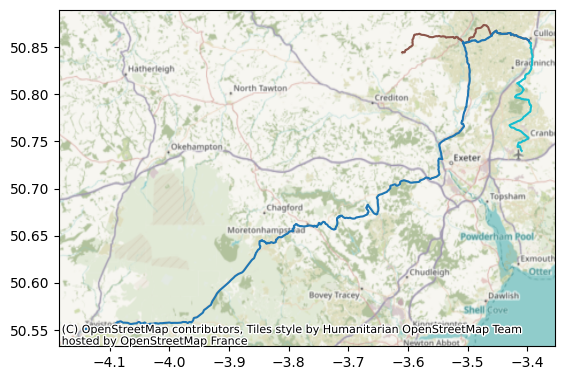

In [15]:
ax = detailed_itineraries.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

#### Repeating this with the modified matrix

Now let's repeat this with our new matrix.

In [16]:
transport_network_modified = r5py.TransportNetwork(
    "../../datasets/devon-260422-modified.osm.pbf",
)

Our travel times appear to be unchanged. 

In [17]:
travel_time_matrix_car_modified = r5py.TravelTimeMatrix(
    transport_network_modified,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

travel_time_matrix_car_modified

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


What about the detailed routes - even if they're probably not right?

In [18]:
detailed_itineraries_modified = r5py.DetailedItineraries(
    transport_network_modified,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,

)

These have changed!

In [19]:
detailed_itineraries_modified

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,21388.334,0 days 00:35:47,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:32:57,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,86600.881,0 days 01:58:39,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


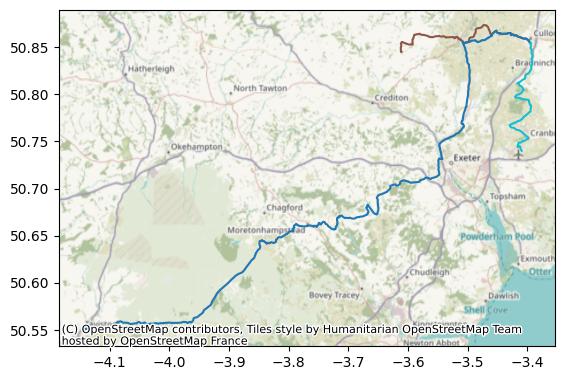

In [20]:
ax = detailed_itineraries_modified.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries_modified.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

#### Repeating with our traffic-altered file

Finally, let's repeat with our traffic-altered file. 

In [21]:
transport_network_modified_traffic = r5py.TransportNetwork(
    "../../datasets/devon-260422-modified-traffic.osm.pbf",
)

Once again, our travel matrix times are unchanged. 

In [22]:
travel_time_matrix_car_modified_traffic = r5py.TravelTimeMatrix(
    transport_network_modified_traffic,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR]
    )

travel_time_matrix_car_modified

,from_id,to_id,travel_time
0,EX15 1HN,EX17 4JG,28
1,EX15 1HN,Exeter Airport,28
2,EX15 1HN,Cornish Arms Tavistock,62


But our detailed itineraries have changed. 

In [23]:
detailed_itineraries_modified_traffic = r5py.DetailedItineraries(
    transport_network_modified_traffic,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],
    snap_to_network=True,

)

In [24]:
detailed_itineraries_modified_traffic

,from_id,to_id,option,segment,transport_mode,departure_time,distance,travel_time,wait_time,feed,agency_id,route_id,start_stop_id,end_stop_id,geometry
0,EX15 1HN,EX17 4JG,0,0,TransportMode.CAR,NaT,21388.334,0 days 00:26:54,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."
1,EX15 1HN,Exeter Airport,0,0,TransportMode.CAR,NaT,20527.246,0 days 00:25:06,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85539, -3.39671 50.855..."
2,EX15 1HN,Cornish Arms Tavistock,0,0,TransportMode.CAR,NaT,85051.652,0 days 01:29:07,0 days,None,None,None,None,None,"LINESTRING (-3.39673 50.85504, -3.39672 50.855..."


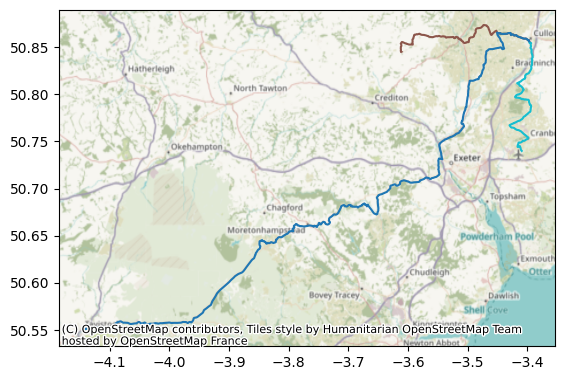

In [25]:
ax = detailed_itineraries_modified_traffic.plot(column="to_id")

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=detailed_itineraries_modified_traffic.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

:::{.callout-note}
### What's going on?

It looks like routingpy uses some other way of calculating travel time when using its matrix function. 

And they're not bad! But it does mean we won't be able to use this method for things like traffic modifications either. 
:::

## Valhalla

Let's compare with valhalla, a routing engine that's much more focussed on car travel times. 

In the past, valhalla had to be set up in a fairly daunting way, but we now have the pyvalhalla option, which is much more approachable!

In [26]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla.json"
)

Using existing Valhalla build


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla.json_traffic.tar'}

In [27]:
travel_time_matrix_car_valhalla = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla.json",
    costing="auto"
)

In [28]:
travel_time_matrix_car_valhalla

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,21.783333,26.503
1,EX15 1HN,Exeter Airport,14.166667,17.259
2,EX15 1HN,Cornish Arms Tavistock,54.383333,89.2


This has worked!

Although compared to google maps, it seems quite optimistic - more so than r5py was. 

![](assets\2026-05-21-10-13-22.png){height=300px}

![](assets\2026-05-21-10-12-28.png){height=300px}

![](assets\2026-05-21-10-13-45.png){height=300px}

We can now repeat this with our modified files. 

In [29]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422-modified.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla-modified"
)

Using existing Valhalla build


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified_traffic.tar'}

In [30]:
travel_time_matrix_car_valhalla_modified = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla-modified.json",
    costing="auto"
)

This looks a little better - but it's still optimistic, and the journey to the Cornish Arms has actually become a tiny bit faster, which is unexpected! 

In [31]:
travel_time_matrix_car_valhalla_modified

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,24.066667,20.382
1,EX15 1HN,Exeter Airport,16.1,23.31
2,EX15 1HN,Cornish Arms Tavistock,54.35,89.2


And finally, let's do this with our very heavy traffic file that assumed all traffic would only be travelling at 60% of the listed road speed. 

In [32]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422-modified-traffic.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla-modified-traffic"
)

Using existing Valhalla build


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified-traffic.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified-traffic_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-modified-traffic_traffic.tar'}

In [33]:
travel_time_matrix_car_valhalla_modified = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla-modified-traffic.json",
    costing="auto"
)

In [34]:
travel_time_matrix_car_valhalla_modified

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,35.05,18.699
1,EX15 1HN,Exeter Airport,25.466667,23.309
2,EX15 1HN,Cornish Arms Tavistock,88.566667,88.944


So we can conclude that valhalla definitely responds to the maximum speed tags in a way that routingpy doesn't - though it's still not a perfect fix. 

:::{.callout-tip}
Routingpy remains an extremely good option if you are interested in public transport. 

Valhalla is probably the better choice if you are looking for car travel times.

Valhalla does also have the benefit of having no java requirements whatsoever - so it's easier to install in locked down environments. 

For some projects, you may end up using a mix of both! 
:::

Let's do one more modified file to see if we can make a difference. 

This time, we'll apply our same substantial slowdown to unclassified roads. 

On top of that, we'll add the assumption that all journies are slower than the posted speed limit on average, so we'll bring speeds down to 90% of reality. 

In [35]:
process_uk_network(
    "../../datasets/devon-260422.osm.pbf",
    "../../datasets/devon-260422-combined-modified.osm.pbf",
    debug=True,
    traffic_multiplier=0.9, # Lower = slower max speed assumed
    minor_road_cap=30,
    debug_limit=100
    )


Reading from C:\lokigi\examples\datasets\devon-260422.osm.pbf
Will write to C:\lokigi\examples\datasets\devon-260422-combined-modified.osm.pbf
Processing C:\lokigi\examples\datasets\devon-260422.osm.pbf...
[WAY 2252] ALL TAGS:
    highway: residential
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Holland Road
[WAY 2252] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2252] residential | original='30 mph' (parsed=30.0) -> new='27.0 (27 mph)' | reasons=['traffic multiplier x0.9'] | inferred_missing=False
[WAY 2253] ALL TAGS:
    highway: tertiary
    lanes: 2
    lit: yes
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
    name: Bradham Lane
    surface: asphalt
[WAY 2253] MAXSPEED-RELATED TAGS:
    maxspeed: 30 mph
    maxspeed:type: GB:nsl_restricted
[WAY 2253] tertiary | original='30 mph' (parsed=30.0) -> new='27.0 (27 mph)' | reasons=['traffic multiplier x0.9'] | inferred_missing=False
[WAY 2255] ALL T

In [36]:
prepare_valhalla_network(
    osm_path="../../datasets/devon-260422-combined-modified.osm.pbf",
    output_dir="../../datasets/",
    output_name="devon-260422_valhalla-combined-modified"
)

Using existing Valhalla build


{'config_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-combined-modified.json',
 'tile_dir': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-combined-modified_tiles',
 'traffic_path': 'C:\\lokigi\\examples\\datasets\\devon-260422_valhalla-combined-modified_traffic.tar'}

In [37]:
travel_time_matrix_car_valhalla_final = build_time_matrix_valhalla(
    origins_gdf=origins,
    destinations_gdf=destinations,
    valhalla_config_path="../../datasets/devon-260422_valhalla-combined-modified.json",
    costing="auto"
)

travel_time_matrix_car_valhalla_final

,from_id,to_id,travel_time_minutes,distance_km
0,EX15 1HN,EX17 4JG,23.783333,18.699
1,EX15 1HN,Exeter Airport,17.5,23.309
2,EX15 1HN,Cornish Arms Tavistock,60.383333,89.2


While this still isn't great for one of our journies, the other two are now quite accurate. 

## Advanced valhalla route inspection and debugging

We can do a bit more debugging... 

In [47]:
def valhalla_maneuvers_to_gdf(response, crs="EPSG:4326", units="km"):
    import polyline
    import geopandas as gpd
    from shapely.geometry import LineString

    rows = []

    for leg_idx, leg in enumerate(response["trip"]["legs"]):

        coords = polyline.decode(leg["shape"], precision=6)

        for m_idx, m in enumerate(leg["maneuvers"]):

            start = m["begin_shape_index"]
            end = m["end_shape_index"]

            segment = coords[start:end+1]

            if len(segment) < 2:
                continue

            geom = LineString([(lon, lat) for lat, lon in segment])

            time_s = m["time"]
            dist = m["length"]

            speed = dist / (time_s / 3600) if time_s > 0 else 0

            rows.append({
                "leg": leg_idx,
                "maneuver": m_idx,
                "instruction": m.get("instruction"),
                "time_s": time_s,
                "distance": dist,
                "speed_kmh": speed,
                "geometry": geom
            })

    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)

    return gdf

In [48]:
from valhalla import Actor

result, summary = valhalla_detailed_route(engine=Actor("../../datasets/devon-260422_valhalla-combined-modified.json"),
                        origin=(origins.iloc[0].latitude, origins.iloc[0].longitude),
                        destination=(destinations.iloc[0].latitude, destinations.iloc[0].longitude),
                        )

result


=== OVERALL ===
Time: 23.8 min
Distance: 11.62 miles

--- LEG 0 ---
Time: 23.8 min
Distance: 11.62 miles
Speed: 29.3 miles/h

Maneuvers:
23.279s | 0.1721 | Drive north on Shortlands Road.
177.943s | 1.3023 | Turn left onto Tiverton Road.
193.822s | 1.4366 | Bear left.
67.676s |  0.479 | Turn left.
8.794s | 0.0596 | Turn left.
41.361s | 0.2746 | Turn right.
13.657s |    0.1 | Turn left.
154.684s | 1.1414 | Turn right.
99.832s | 0.7052 | Turn right.
54.456s | 0.2516 | Turn right.
32.896s | 0.2491 | Turn right onto A396.
201.203s | 2.8471 | Turn left onto A3072.
47.666s | 0.3324 | Turn right onto Uppincott Lane.
56.956s | 0.4212 | Turn left.
240.096s | 1.7789 | Keep left at the fork.
12.825s | 0.0671 | Turn right.
 0.0s |    0.0 | Your destination is on the right.


{'trip': {'locations': [{'type': 'break',
    'lat': 50.855107,
    'lon': -3.396451,
    'side_of_street': 'right',
    'original_index': 0},
   {'type': 'break',
    'lat': 50.844712,
    'lon': -3.610281,
    'side_of_street': 'right',
    'original_index': 1}],
  'legs': [{'maneuvers': [{'type': 2,
      'instruction': 'Drive north on Shortlands Road.',
      'verbal_succinct_transition_instruction': 'Drive north. Then, in 900 feet, Turn left onto Tiverton Road.',
      'verbal_pre_transition_instruction': 'Drive north on Shortlands Road. Then, in 900 feet, Turn left onto Tiverton Road.',
      'verbal_post_transition_instruction': 'Continue for 900 feet.',
      'street_names': ['Shortlands Road'],
      'bearing_after': 4,
      'time': 23.279,
      'length': 0.1721,
      'cost': 34.167,
      'begin_shape_index': 0,
      'end_shape_index': 18,
      'verbal_multi_cue': True,
      'travel_mode': 'drive',
      'travel_type': 'car'},
     {'type': 15,
      'instruction': 'Tur

In [49]:
summary

{'total_time_s': 1427.153,
 'total_dist': 11.6191,
 'legs': [{'leg_index': 0,
   'time_s': 1427.153,
   'distance': 11.6191,
   'speed': 29.309233137582304}]}

In [50]:
valhalla_audit_route_speeds(result)


=== ROUTE SUMMARY ===
Total time: 23.8 min
Total dist: 11.62 km

=== SPEED DISTRIBUTION ===
< 20 km/h (urban/stop-start)        | time:    1.1 min (  4.7%) | dist:    0.3 km (  2.7%)
20–40 km/h (dense urban)            | time:   19.3 min ( 81.2%) | dist:    8.5 km ( 72.8%)
40–60 km/h (suburban)               | time:    3.4 min ( 14.1%) | dist:    2.8 km ( 24.5%)
60–90 km/h (A-road)                 | time:    0.0 min (  0.0%) | dist:    0.0 km (  0.0%)
90+ km/h (motorway-like)            | time:    0.0 min (  0.0%) | dist:    0.0 km (  0.0%)


{'total_time_s': 1427.146,
 'total_dist_km': 11.6182,
 'band_stats': {'20–40 km/h (dense urban)': {'time': 1158.6619999999998,
   'dist': 8.452399999999999},
  '< 20 km/h (urban/stop-start)': {'time': 67.281, 'dist': 0.3187},
  '40–60 km/h (suburban)': {'time': 201.203, 'dist': 2.8471},
  '60–90 km/h (A-road)': {'time': 0.0, 'dist': 0.0},
  '90+ km/h (motorway-like)': {'time': 0.0, 'dist': 0.0}}}

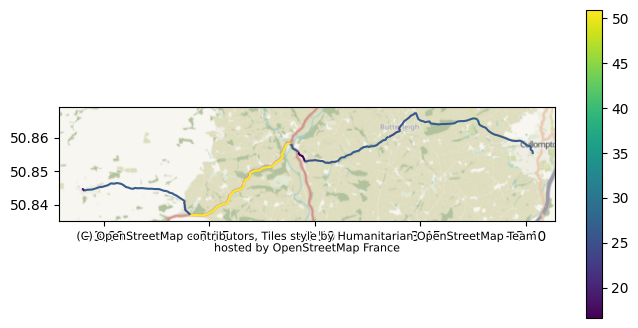

In [51]:
result_gdf = valhalla_maneuvers_to_gdf(result)

ax = result_gdf.plot(column="speed_kmh", legend=True, figsize=(8,4))

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=result_gdf.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

# Grab the auto-generated attribution object from matplotlib axes
txt = ax.texts[-1]
# Adjust its position to outside the map, just below the bottom edge
txt.set_position([0.5, -0.1])
txt.set_ha('center') # Center the text
txt.set_va('top')

Let's repeat this for our other routes. 

#### To Exeter Airport

In [52]:
result, summary = valhalla_detailed_route(engine=Actor("../../datasets/devon-260422_valhalla-combined-modified.json"),
                        origin=(origins.iloc[0].latitude, origins.iloc[0].longitude),
                        destination=(destinations.iloc[1].latitude, destinations.iloc[1].longitude),
                        )

result


=== OVERALL ===
Time: 17.5 min
Distance: 14.48 miles

--- LEG 0 ---
Time: 17.5 min
Distance: 14.48 miles
Speed: 49.6 miles/h

Maneuvers:
23.279s | 0.1721 | Drive north on Shortlands Road.
32.749s | 0.2025 | Turn right onto Tiverton Road.
17.196s |  0.118 | Turn left onto High Street/B3181.
23.658s | 0.1584 | Turn right onto Station Road/B3181.
1.606s | 0.0118 | Enter the roundabout and take the 1st exit onto Station Road/B3181.
9.096s | 0.0671 | Exit the roundabout onto Station Road/B3181.
9.91s | 0.0223 | Enter the roundabout and take the 2nd exit onto Station Road/B3181.
17.397s | 0.1273 | Exit the roundabout onto Station Road/B3181.
3.722s | 0.0223 | Enter the roundabout and take the 3rd exit onto Station Road/A373.
6.367s | 0.0466 | Exit the roundabout onto Station Road/A373. Continue on A373.
574.004s | 9.9431 | Turn right to take the M5 ramp.
16.461s | 0.2858 | Take exit 29 toward Honiton/Exeter Airport.
73.52s | 1.1346 | Bear left onto A30/Honiton Road. Continue on A30.
17.467s

{'trip': {'locations': [{'type': 'break',
    'lat': 50.855107,
    'lon': -3.396451,
    'side_of_street': 'right',
    'original_index': 0},
   {'type': 'break',
    'lat': 50.737141,
    'lon': -3.413323,
    'side_of_street': 'right',
    'original_index': 1}],
  'legs': [{'maneuvers': [{'type': 2,
      'instruction': 'Drive north on Shortlands Road.',
      'verbal_succinct_transition_instruction': 'Drive north. Then, in 900 feet, Turn right onto Tiverton Road.',
      'verbal_pre_transition_instruction': 'Drive north on Shortlands Road. Then, in 900 feet, Turn right onto Tiverton Road.',
      'verbal_post_transition_instruction': 'Continue for 900 feet.',
      'street_names': ['Shortlands Road'],
      'bearing_after': 4,
      'time': 23.279,
      'length': 0.1721,
      'cost': 34.167,
      'begin_shape_index': 0,
      'end_shape_index': 18,
      'verbal_multi_cue': True,
      'travel_mode': 'drive',
      'travel_type': 'car'},
     {'type': 10,
      'instruction': 'T

In [53]:
summary

{'total_time_s': 1050.746,
 'total_dist': 14.4843,
 'legs': [{'leg_index': 0,
   'time_s': 1050.746,
   'distance': 14.4843,
   'speed': 49.625199620079435}]}

In [54]:
valhalla_audit_route_speeds(result)


=== ROUTE SUMMARY ===
Total time: 17.5 min
Total dist: 14.48 km

=== SPEED DISTRIBUTION ===
< 20 km/h (urban/stop-start)        | time:    0.2 min (  0.9%) | dist:    0.0 km (  0.2%)
20–40 km/h (dense urban)            | time:    6.0 min ( 34.0%) | dist:    2.8 km ( 19.6%)
40–60 km/h (suburban)               | time:    1.6 min (  8.9%) | dist:    1.4 km (  9.6%)
60–90 km/h (A-road)                 | time:    9.8 min ( 56.2%) | dist:   10.2 km ( 70.6%)
90+ km/h (motorway-like)            | time:    0.0 min (  0.0%) | dist:    0.0 km (  0.0%)


{'total_time_s': 1050.737,
 'total_dist_km': 14.483400000000001,
 'band_stats': {'20–40 km/h (dense urban)': {'time': 357.20799999999997,
   'dist': 2.8386},
  '< 20 km/h (urban/stop-start)': {'time': 9.91, 'dist': 0.0223},
  '60–90 km/h (A-road)': {'time': 590.465, 'dist': 10.2289},
  '40–60 km/h (suburban)': {'time': 93.154, 'dist': 1.3936000000000002},
  '90+ km/h (motorway-like)': {'time': 0.0, 'dist': 0.0}}}

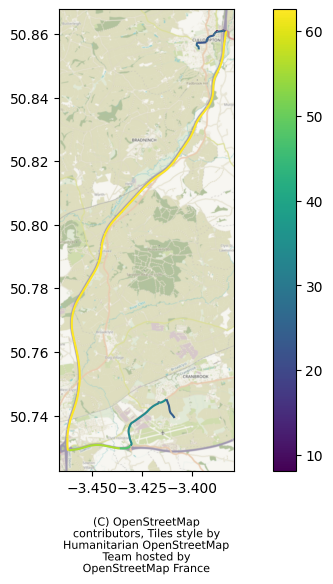

In [55]:
result_gdf = valhalla_maneuvers_to_gdf(result)

ax = result_gdf.plot(column="speed_kmh", legend=True, figsize=(10,6))

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=result_gdf.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

# Grab the auto-generated attribution object from matplotlib axes
txt = ax.texts[-1]
# Adjust its position to outside the map, just below the bottom edge
txt.set_position([0.5, -0.1])
txt.set_ha('center') # Center the text
txt.set_va('top')

### Cullompton to Tavistock (Cornish Arms)

In [56]:
result, summary = valhalla_detailed_route(
    engine=Actor("../../datasets/devon-260422_valhalla-combined-modified.json"),
    origin=(origins.iloc[0].latitude, origins.iloc[0].longitude),
    destination=(destinations.iloc[2].latitude, destinations.iloc[2].longitude),
    )

result


=== OVERALL ===
Time: 60.4 min
Distance: 55.43 miles

--- LEG 0 ---
Time: 60.4 min
Distance: 55.43 miles
Speed: 55.1 miles/h

Maneuvers:
23.279s | 0.1721 | Drive north on Shortlands Road.
32.749s | 0.2025 | Turn right onto Tiverton Road.
17.196s |  0.118 | Turn left onto High Street/B3181.
23.658s | 0.1584 | Turn right onto Station Road/B3181.
1.606s | 0.0118 | Enter the roundabout and take the 1st exit onto Station Road/B3181.
9.096s | 0.0671 | Exit the roundabout onto Station Road/B3181.
9.91s | 0.0223 | Enter the roundabout and take the 2nd exit onto Station Road/B3181.
17.397s | 0.1273 | Exit the roundabout onto Station Road/B3181.
3.722s | 0.0223 | Enter the roundabout and take the 3rd exit onto Station Road/A373.
6.367s | 0.0466 | Exit the roundabout onto Station Road/A373. Continue on A373.
843.429s | 14.6388 | Turn right to take the M5 ramp.
54.772s | 0.7083 | Keep left to take exit 31 onto A30.
1525.255s | 26.5816 | Continue on A30.
13.947s | 0.2429 | Take the Sourton Cross e

{'trip': {'locations': [{'type': 'break',
    'lat': 50.855107,
    'lon': -3.396451,
    'side_of_street': 'right',
    'original_index': 0},
   {'type': 'break', 'lat': 50.551448, 'lon': -4.14675, 'original_index': 1}],
  'legs': [{'maneuvers': [{'type': 2,
      'instruction': 'Drive north on Shortlands Road.',
      'verbal_succinct_transition_instruction': 'Drive north. Then, in 900 feet, Turn right onto Tiverton Road.',
      'verbal_pre_transition_instruction': 'Drive north on Shortlands Road. Then, in 900 feet, Turn right onto Tiverton Road.',
      'verbal_post_transition_instruction': 'Continue for 900 feet.',
      'street_names': ['Shortlands Road'],
      'bearing_after': 4,
      'time': 23.279,
      'length': 0.1721,
      'cost': 34.167,
      'begin_shape_index': 0,
      'end_shape_index': 18,
      'verbal_multi_cue': True,
      'travel_mode': 'drive',
      'travel_type': 'car'},
     {'type': 10,
      'instruction': 'Turn right onto Tiverton Road.',
      'verba

In [57]:
summary

{'total_time_s': 3623.905,
 'total_dist': 55.4261,
 'legs': [{'leg_index': 0,
   'time_s': 3623.905,
   'distance': 55.4261,
   'speed': 55.06048309765294}]}

In [58]:
valhalla_audit_route_speeds(result)


=== ROUTE SUMMARY ===
Total time: 60.4 min
Total dist: 55.43 km

=== SPEED DISTRIBUTION ===
< 20 km/h (urban/stop-start)        | time:    0.3 min (  0.5%) | dist:    0.0 km (  0.1%)
20–40 km/h (dense urban)            | time:    3.2 min (  5.4%) | dist:    1.4 km (  2.4%)
40–60 km/h (suburban)               | time:   17.1 min ( 28.4%) | dist:   12.6 km ( 22.7%)
60–90 km/h (A-road)                 | time:   39.7 min ( 65.7%) | dist:   41.5 km ( 74.8%)
90+ km/h (motorway-like)            | time:    0.0 min (  0.0%) | dist:    0.0 km (  0.0%)


{'total_time_s': 3623.896,
 'total_dist_km': 55.42519999999999,
 'band_stats': {'20–40 km/h (dense urban)': {'time': 194.921, 'dist': 1.3539},
  '< 20 km/h (urban/stop-start)': {'time': 17.863, 'dist': 0.0434},
  '60–90 km/h (A-road)': {'time': 2382.6310000000003, 'dist': 41.4633},
  '40–60 km/h (suburban)': {'time': 1028.481, 'dist': 12.564599999999999},
  '90+ km/h (motorway-like)': {'time': 0.0, 'dist': 0.0}}}

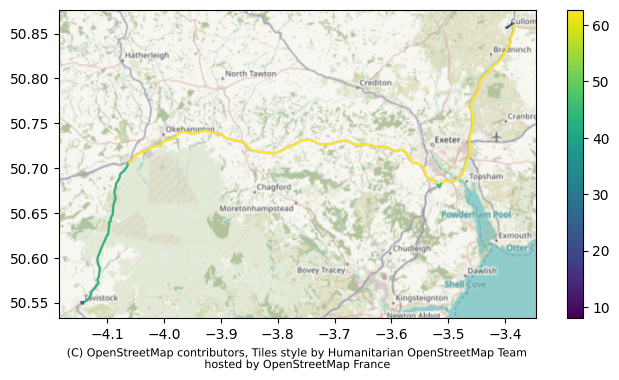

In [59]:
result_gdf = valhalla_maneuvers_to_gdf(result)

ax = result_gdf.plot(column="speed_kmh", legend=True, figsize=(8,4))

cx.add_basemap(
    ax, # the figure we created using our plot method
    crs=result_gdf.crs.to_string(), # we can pull the CRS out of the geodataframe!
    )

# Grab the auto-generated attribution object from matplotlib axes
txt = ax.texts[-1]
# Adjust its position to outside the map, just below the bottom edge
txt.set_position([0.5, -0.1])
txt.set_ha('center') # Center the text
txt.set_va('top')

If we are familiar with these routes, this might help us better understand where valhalla is overestimating or underestimating speeds. 